# Notebook 08 — Capa Clínica
**Predicción de Diagnóstico de Cáncer · UAX 2025/2026**

Sección cubierta: **Sección 8 — Del modelo al umbral operativo**

Convierte los resultados estadísticos en decisiones clínicas concretas.

Contenido:
- 8.1 Carga de artefactos
- 8.2 Curvas de calibración — ¿son fiables las probabilidades?
- 8.3 Optimización de umbral por coste asimétrico
- 8.4 Decision Curve Analysis (DCA)
- 8.5 Escenario Recall ≥ 0.90 — coste de no perder cánceres
- 8.6 Comparación Oracle vs modelos reales
- 8.7 Traducción clínica concreta

**Carga:** probabilidades de notebooks 05 y 06, resultados de notebook 07
**Genera:** figuras para slides + `outputs/tables/clinical_summary.csv`

---
## Setup

In [16]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    brier_score_loss, average_precision_score,
    confusion_matrix, precision_recall_curve, roc_curve,
)
from sklearn.calibration import calibration_curve
from dcurves import dca, plot_graphs

warnings.filterwarnings('ignore')

ROOT      = os.path.abspath('..')
DATA_PROC = os.path.join(ROOT, 'data', 'processed')
OUT_FIGS  = os.path.join(ROOT, 'outputs', 'figures')
OUT_TABS  = os.path.join(ROOT, 'outputs', 'tables')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

COLORS = {'LogReg (baseline)': '#888888', 'Random Forest': '#6ACC65',
          'XGBoost': '#D65F5F', 'LightGBM': '#B47CC7',
          'MLP': '#4878CF', 'Oracle': '#333333'}

COST_FN = 5   # coste relativo de un Falso Negativo
COST_FP = 1   # coste relativo de un Falso Positivo

---
## 8.1 Carga de artefactos

In [17]:
y_test = np.load(os.path.join(DATA_PROC, 'y_test.npy'))

with open(os.path.join(DATA_PROC, 'meta.json')) as f:
    meta = json.load(f)
with open(os.path.join(DATA_PROC, 'mlp_meta.json')) as f:
    mlp_meta = json.load(f)

THRESHOLD_MLP = mlp_meta['threshold_optimal']
ORACLE_AUC    = meta['oracle_auc']

probas_classical = joblib.load(os.path.join(DATA_PROC, 'probas_classical.joblib'))
y_proba_mlp      = np.load(os.path.join(DATA_PROC, 'probas_mlp.npy'))

X_test_raw = pd.read_parquet(os.path.join(DATA_PROC, 'X_test_raw.parquet'))

def compute_oracle(df):
    logit = (
        -4.0
        + 2.0 * df['mut_BRCA1'] + 1.8 * df['mut_TP53']
        + 1.5 * df['fumador']   + 1.4 * df['mut_KRAS']
        + 1.2 * (df['glucosa'] > 130).astype(int)
        + 1.1 * df['obesidad']  + 1.0 * df['mut_EGFR']
        + 0.9 * (df['hemoglobina'] < 11).astype(int)
        + 0.8 * df['mut_PIK3CA']
        + 0.7 * (df['leucocitos'] > 10).astype(int)
        + 0.6 * df['mut_BRAF']  + 0.5 * df['hipertension']
        + 0.4 * (df['edad'] > 55).astype(int)
    )
    if 'actividad_fisica_ord' in df.columns:
        logit += -1.2 * (df['actividad_fisica_ord'] == 2).astype(int)
        logit += -0.6 * (df['actividad_fisica_ord'] == 1).astype(int)
    return 1 / (1 + np.exp(-logit))

oracle_test = compute_oracle(X_test_raw).values

ALL_PROBAS = {**probas_classical, 'MLP': y_proba_mlp}
THRESHOLDS = {m: 0.50 for m in probas_classical}
THRESHOLDS['MLP'] = THRESHOLD_MLP

print(f"Test: {len(y_test):,} pacientes  |  prevalencia: {y_test.mean():.4f}")
print(f"Oracle AUC: {roc_auc_score(y_test, oracle_test):.4f}  (techo teorico)")

Test: 10,001 pacientes  |  prevalencia: 0.1929
Oracle AUC: 0.8362  (techo teorico)


---
## 8.2 Curvas de calibración

Un modelo bien calibrado es aquel donde su probabilidad predicha coincide
con la frecuencia real observada. Si el modelo dice "30% de probabilidad de
cáncer", el 30% de esos pacientes debería tener cáncer realmente.

La calibración es el fundamento matemático que valida el análisis de coste
y la DCA: si las probabilidades son solo scores de ranking (no estimaciones
reales), los umbrales clínicos derivados no tienen interpretación directa.

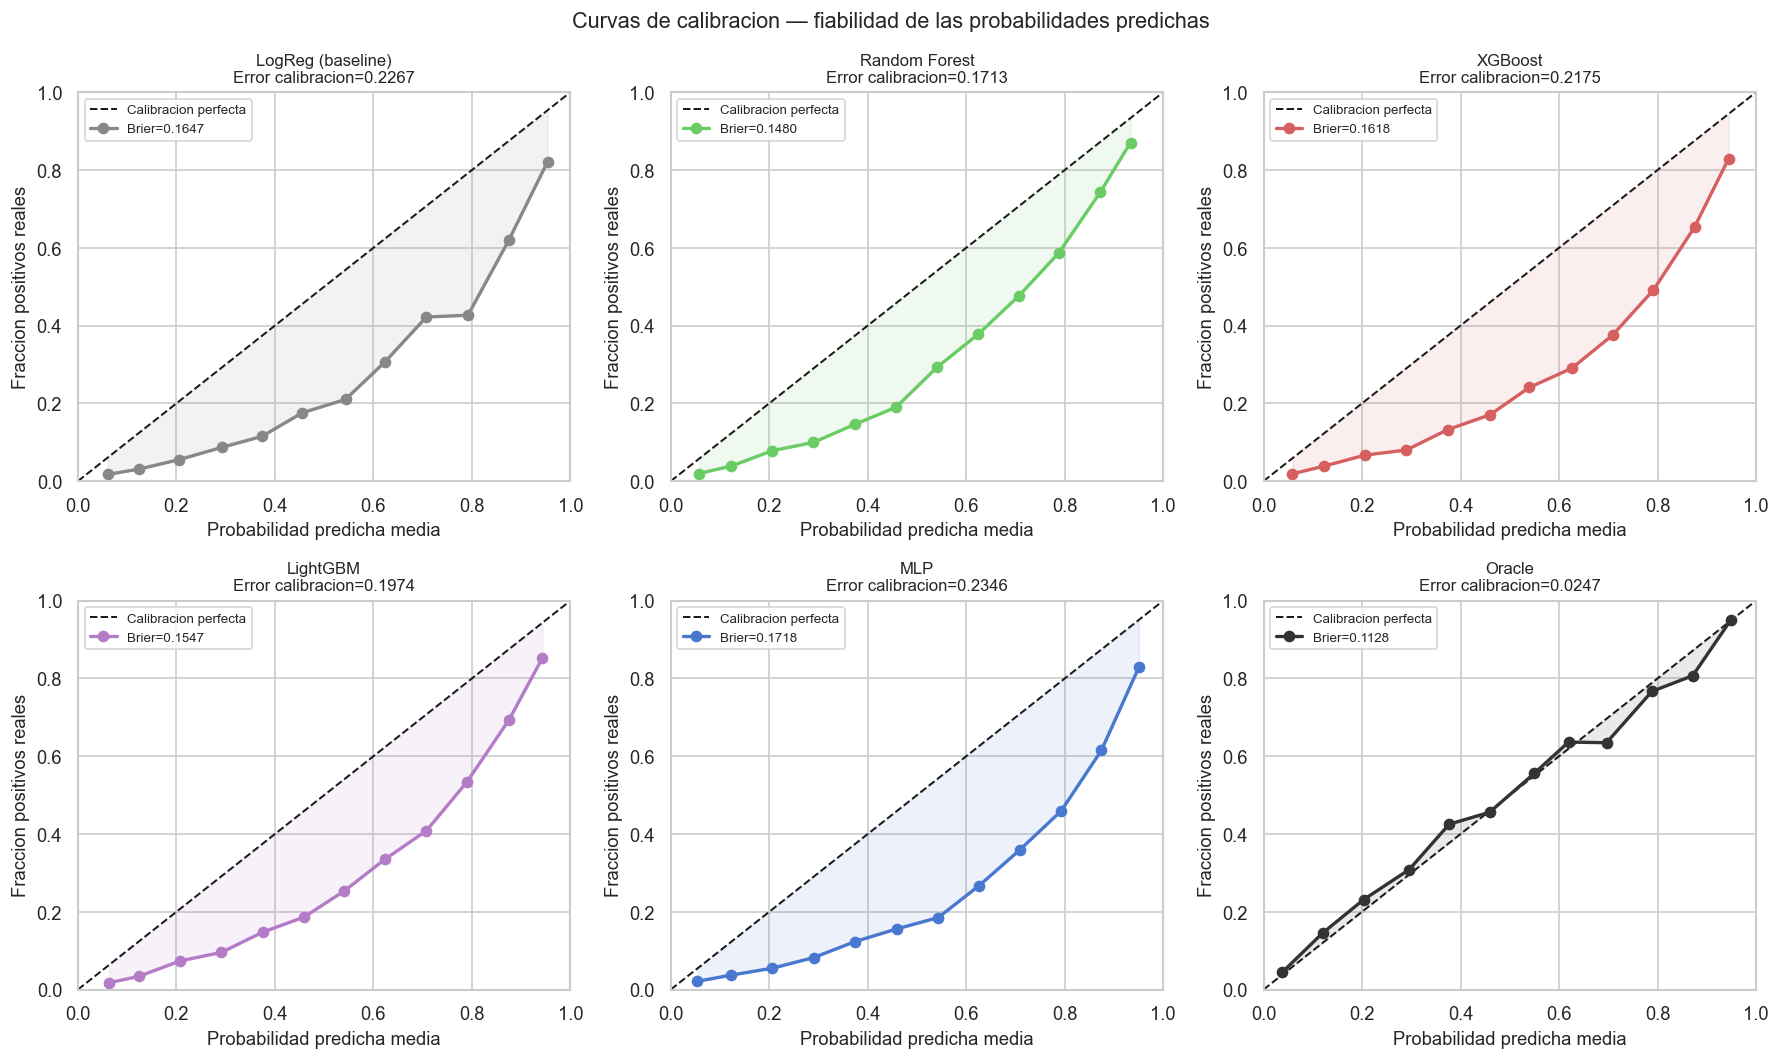


=== Resumen de calibracion ===
           modelo  brier_score  calib_error_medio  bien_calibrado
LogReg (baseline)       0.1647             0.2267           False
    Random Forest       0.1480             0.1713           False
          XGBoost       0.1618             0.2175           False
         LightGBM       0.1547             0.1974           False
              MLP       0.1718             0.2346           False
           Oracle       0.1128             0.0247            True

Brier Score: mas bajo es mejor. < 0.15 = bien calibrado para uso clinico.


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

calibration_results = []

for ax, (name, proba) in zip(axes, {**ALL_PROBAS, 'Oracle': oracle_test}.items()):
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=12)
    brier = brier_score_loss(y_test, proba)

    ax.plot([0,1],[0,1],'k--', linewidth=1.2, label='Calibracion perfecta')
    ax.plot(mean_pred, frac_pos, 'o-', color=COLORS.get(name,'#999'),
            linewidth=2, markersize=6, label=f'Brier={brier:.4f}')
    ax.fill_between(mean_pred, frac_pos, mean_pred,
                    alpha=0.1, color=COLORS.get(name,'#999'))

    # Calcular desviacion media de calibracion
    calib_err = np.mean(np.abs(frac_pos - mean_pred))
    ax.set_title(f'{name}\nError calibracion={calib_err:.4f}', fontsize=10)
    ax.set_xlabel('Probabilidad predicha media')
    ax.set_ylabel('Fraccion positivos reales')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    calibration_results.append({
        'modelo': name,
        'brier_score': round(brier, 4),
        'calib_error_medio': round(calib_err, 4),
        'bien_calibrado': calib_err < 0.05
    })

plt.suptitle('Curvas de calibracion — fiabilidad de las probabilidades predichas',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '23_calibration_curves.png'), bbox_inches='tight')
plt.show()

df_cal = pd.DataFrame(calibration_results)
print("\n=== Resumen de calibracion ===")
print(df_cal.to_string(index=False))
print("\nBrier Score: mas bajo es mejor. < 0.15 = bien calibrado para uso clinico.")

---
## 8.3 Optimización de umbral por coste asimétrico

En oncología, no detectar un cáncer (FN) tiene un coste clínico mucho mayor
que una falsa alarma (FP). Definimos la función de coste total:

```
Coste(umbral) = COST_FN × FN(umbral) + COST_FP × FP(umbral)
```

Con `COST_FN = 5` y `COST_FP = 1`: no detectar un cáncer cuesta 5 veces
más que una alarma innecesaria. El umbral óptimo minimiza esta función.

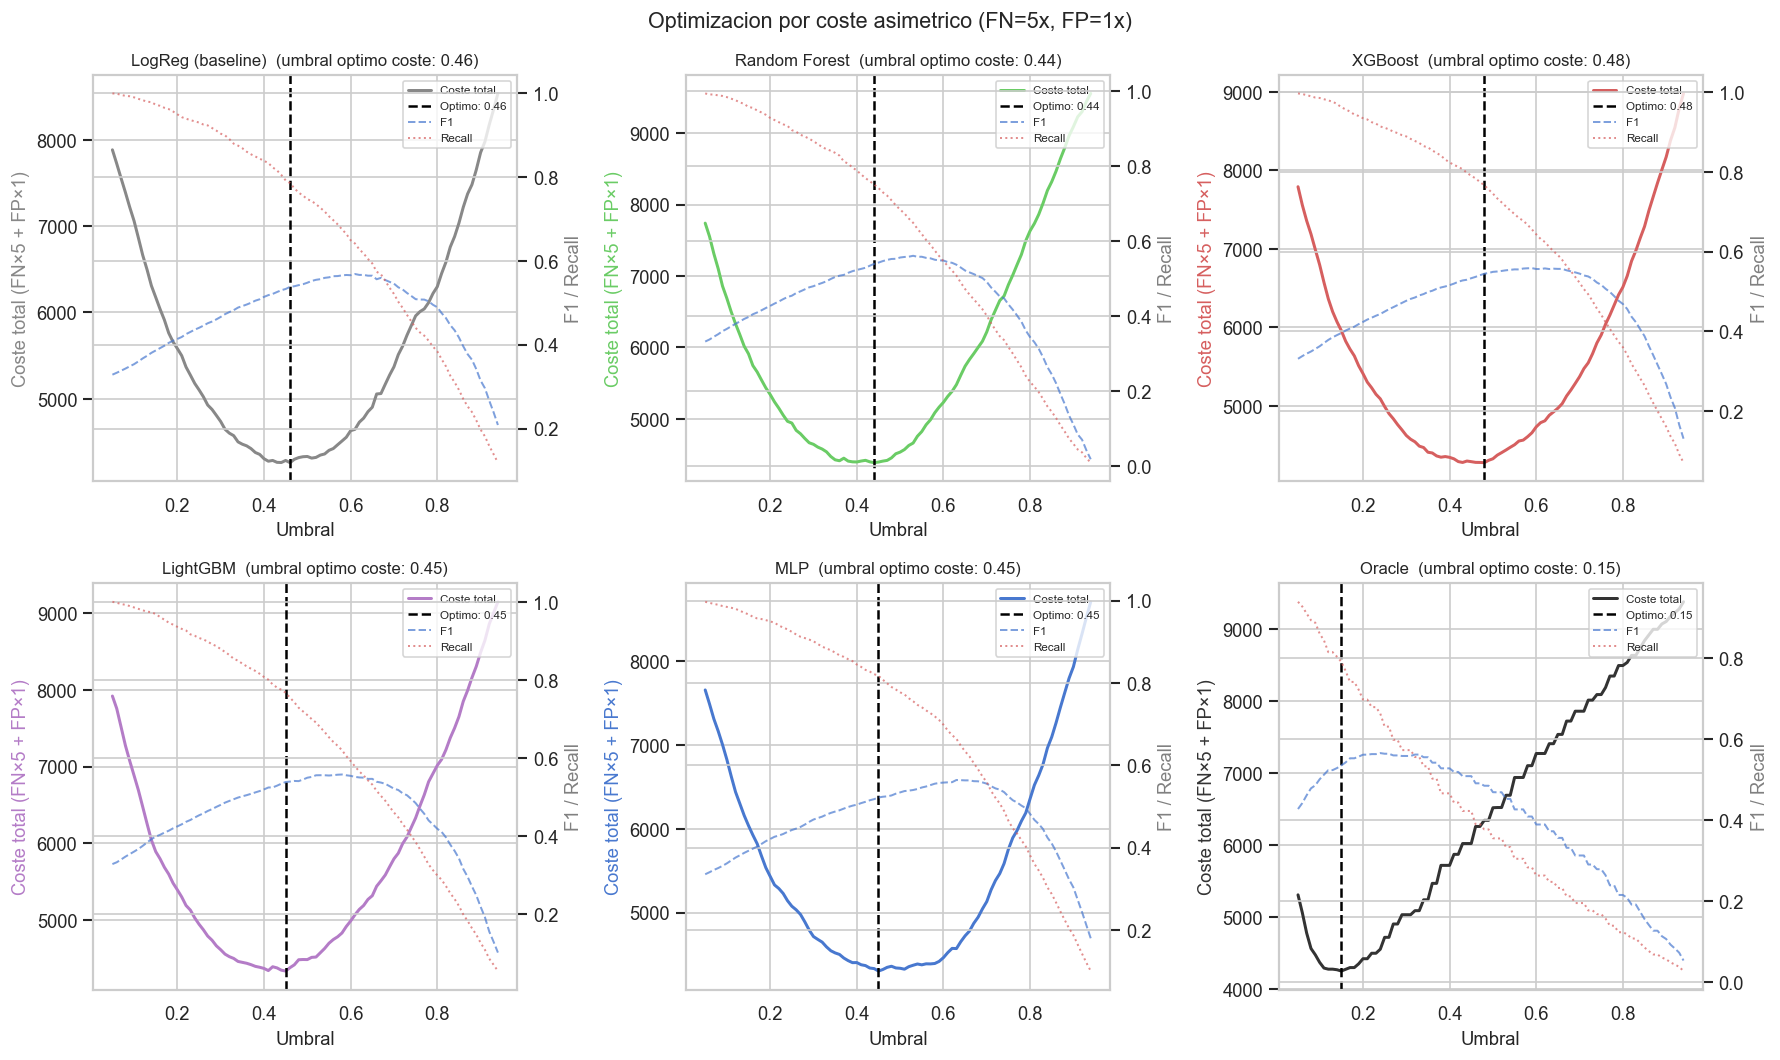

Umbrales optimos por coste asimetrico:
Modelo                      Umbral   Recall  Precision     FN     FP
-----------------------------------------------------------------
  LogReg (baseline)           0.46   0.7854     0.4089    414   2190
  Random Forest               0.44   0.7517     0.4214    479   1991
  XGBoost                     0.48   0.7667     0.4222    450   2024
  LightGBM                    0.45   0.7667     0.4144    450   2090
  MLP                         0.45   0.8170     0.3830    353   2539
  Oracle                      0.15   0.7916     0.4047    402   2246


In [19]:
def coste_total(y_true, y_proba, threshold, cfn=COST_FN, cfp=COST_FP):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return cfn * fn + cfp * fp

thresholds_range = np.arange(0.05, 0.95, 0.01)
cost_optimal = {}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, (name, proba) in zip(axes, {**ALL_PROBAS, 'Oracle': oracle_test}.items()):
    costs  = [coste_total(y_test, proba, t) for t in thresholds_range]
    f1s    = [f1_score(y_test, (proba>=t).astype(int), zero_division=0)
              for t in thresholds_range]
    recalls= [recall_score(y_test, (proba>=t).astype(int), zero_division=0)
              for t in thresholds_range]

    opt_t = float(thresholds_range[np.argmin(costs)])
    cost_optimal[name] = opt_t

    col = COLORS.get(name, '#999')
    ax2 = ax.twinx()
    ax.plot(thresholds_range, costs,   color=col,        linewidth=1.8, label='Coste total')
    ax2.plot(thresholds_range, f1s,    color='#4878CF',  linewidth=1.2,
             linestyle='--', alpha=0.7, label='F1')
    ax2.plot(thresholds_range, recalls,color='#D65F5F',  linewidth=1.2,
             linestyle=':', alpha=0.7, label='Recall')
    ax.axvline(opt_t, color='black', linestyle='--', linewidth=1.5,
               label=f'Optimo: {opt_t:.2f}')
    ax.set_title(f'{name}  (umbral optimo coste: {opt_t:.2f})', fontsize=10)
    ax.set_xlabel('Umbral')
    ax.set_ylabel(f'Coste total (FN×{COST_FN} + FP×{COST_FP})', color=col)
    ax2.set_ylabel('F1 / Recall', color='gray')
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labs1+labs2, fontsize=7, loc='upper right')

plt.suptitle(f'Optimizacion por coste asimetrico (FN={COST_FN}x, FP={COST_FP}x)',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '24_cost_threshold_optimization.png'), bbox_inches='tight')
plt.show()

print("Umbrales optimos por coste asimetrico:")
print(f"{'Modelo':<25} {'Umbral':>8} {'Recall':>8} {'Precision':>10} {'FN':>6} {'FP':>6}")
print("-" * 65)
for name, thr in cost_optimal.items():
    proba = ALL_PROBAS.get(name, oracle_test)
    y_pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f"  {name:<23} {thr:>8.2f} "
          f"{recall_score(y_test,y_pred):>8.4f} "
          f"{precision_score(y_test,y_pred,zero_division=0):>10.4f} "
          f"{fn:>6} {fp:>6}")

---
## 8.4 Decision Curve Analysis (DCA)

Mide el **beneficio neto** de usar cada modelo para distintas probabilidades
umbral de tratamiento. Responde: ¿aporta este modelo más valor que
"tratar a todos" o "no tratar a ninguno"?

Es la herramienta estándar en epidemiología clínica para adoptar o rechazar
modelos de cribado. Un modelo con beneficio neto positivo en el rango de
umbrales de interés clínico (≈0.10–0.40 en oncología) es clínicamente útil.

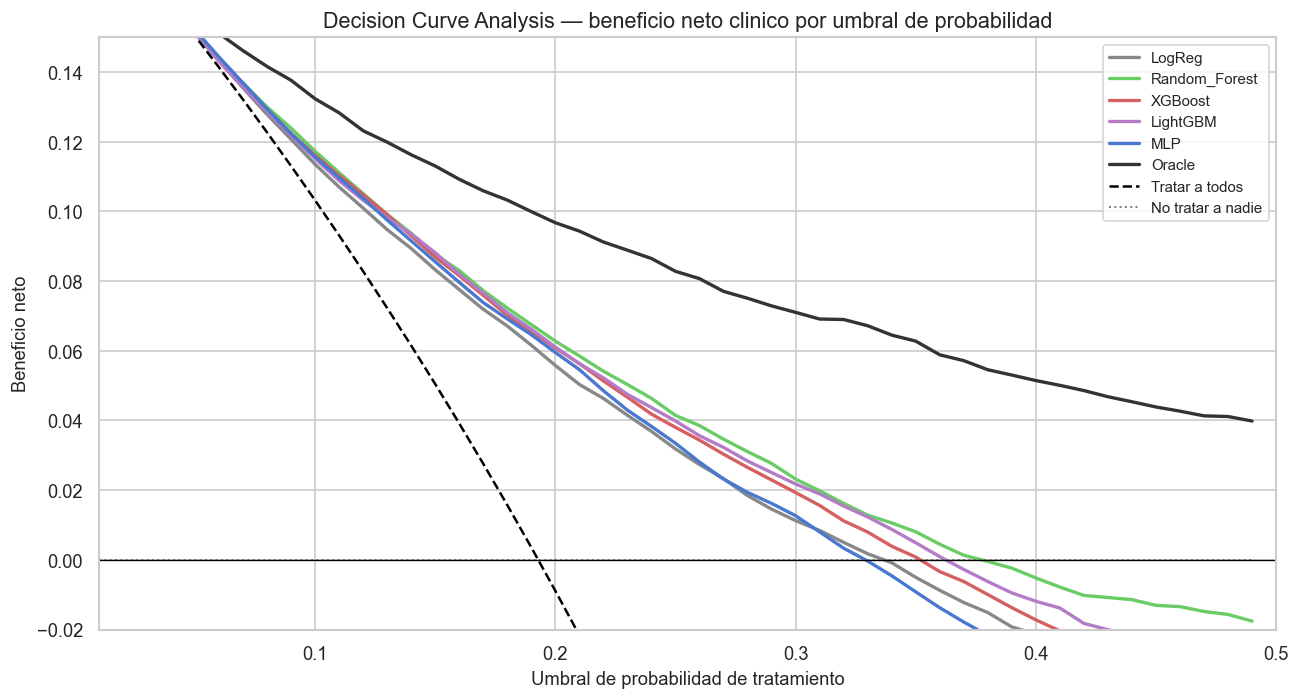

Interpretacion:
  Los modelos que superan 'Tratar a todos' y 'No tratar' tienen
  utilidad clinica neta positiva en ese rango de umbrales.
  Rango de interes clinico en cribado oncologico: 0.10 - 0.35


In [25]:
dca_df = pd.DataFrame({
    'cancer':        y_test,
    'LogReg':        probas_classical['LogReg (baseline)'],
    'Random_Forest': probas_classical['Random Forest'],
    'XGBoost':       probas_classical['XGBoost'],
    'LightGBM':      probas_classical['LightGBM'],
    'MLP':           y_proba_mlp,
    'Oracle':        oracle_test,
}, index=range(len(y_test)))

dca_result = dca(
    data=dca_df,
    outcome='cancer',
    modelnames=['LogReg','Random_Forest','XGBoost','LightGBM','MLP','Oracle'],
    thresholds=np.arange(0.01, 0.50, 0.01),
)

# Implementacion manual del grafico DCA con matplotlib
fig, ax = plt.subplots(figsize=(11, 6))

model_colors = {
    'LogReg':        '#888888',
    'Random_Forest': '#6ACC65',
    'XGBoost':       '#D65F5F',
    'LightGBM':      '#B47CC7',
    'MLP':           '#4878CF',
    'Oracle':        '#333333',
}

for model_name in dca_result['model'].unique():
    subset = dca_result[dca_result['model'] == model_name]
    if model_name == 'all':
        ax.plot(subset['threshold'], subset['net_benefit'],
                color='black', linewidth=1.5, linestyle='--', label='Tratar a todos')
    elif model_name == 'none':
        ax.plot(subset['threshold'], subset['net_benefit'],
                color='gray', linewidth=1.2, linestyle=':', label='No tratar a nadie')
    else:
        col = model_colors.get(model_name, '#999999')
        ax.plot(subset['threshold'], subset['net_benefit'],
                color=col, linewidth=2, label=model_name)

ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlim(0.01, 0.50)
ax.set_ylim(-0.02, 0.15)
ax.set_xlabel('Umbral de probabilidad de tratamiento')
ax.set_ylabel('Beneficio neto')
ax.set_title('Decision Curve Analysis — beneficio neto clinico por umbral de probabilidad')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '25_decision_curve_analysis.png'), bbox_inches='tight')
plt.show()

print("Interpretacion:")
print("  Los modelos que superan 'Tratar a todos' y 'No tratar' tienen")
print("  utilidad clinica neta positiva en ese rango de umbrales.")
print("  Rango de interes clinico en cribado oncologico: 0.10 - 0.35")


---
## 8.5 Escenario Recall ≥ 0.90

Si el hospital exige no perder más del 10% de los cánceres,
¿qué umbral necesitamos, qué precisión obtenemos y cuántas
falsas alarmas generamos por cada 1.000 pacientes?

In [26]:
TARGET_RECALL = 0.90
N_PROJ = 1000
prev   = y_test.mean()

rows_90 = []
for name, proba in {**ALL_PROBAS, 'Oracle': oracle_test}.items():
    thrs   = np.arange(0.01, 0.99, 0.005)
    recalls_s = [recall_score(y_test, (proba>=t).astype(int), zero_division=0)
                 for t in thrs]

    # Umbral mas alto con recall >= TARGET_RECALL
    candidates = [(t, r) for t, r in zip(thrs, recalls_s) if r >= TARGET_RECALL]
    if candidates:
        thr_90 = float(max(candidates, key=lambda x: x[0])[0])
    else:
        thr_90 = float(thrs[np.argmax(recalls_s)])

    y_pred_90 = (proba >= thr_90).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_90).ravel()

    # Proyeccion a N_PROJ pacientes
    n_pos_proj = int(N_PROJ * prev)
    n_neg_proj = N_PROJ - n_pos_proj
    tp_proj = int(n_pos_proj * recall_score(y_test, y_pred_90))
    fn_proj = n_pos_proj - tp_proj
    fp_proj = int(n_neg_proj * (fp / (fp+tn+1e-9)))

    rows_90.append({
        'modelo':           name,
        'umbral_r90':       round(thr_90, 2),
        'recall_real':      round(recall_score(y_test, y_pred_90), 4),
        'precision_real':   round(precision_score(y_test, y_pred_90, zero_division=0), 4),
        'fn_test':          fn,
        'fp_test':          fp,
        f'canceres_detectados/{N_PROJ}': tp_proj,
        f'canceres_perdidos/{N_PROJ}':   fn_proj,
        f'falsas_alarmas/{N_PROJ}':      fp_proj,
    })

df_90 = pd.DataFrame(rows_90)
print(f"=== Escenario Recall >= {TARGET_RECALL} (proyectado a {N_PROJ} pacientes) ===")
print()
display(df_90)
print()
print(f"Interpretacion: para garantizar Recall >= {TARGET_RECALL},")
print(f"hay que bajar el umbral de clasificacion, lo que aumenta las falsas alarmas.")
print(f"El modelo con mejor balance coste/beneficio en este escenario es el que")
print(f"minimiza las falsas alarmas manteniendo el recall objetivo.")

=== Escenario Recall >= 0.9 (proyectado a 1000 pacientes) ===



,modelo,umbral_r90,recall_real,precision_real,fn_test,fp_test,canceres_detectados/1000,canceres_perdidos/1000,falsas_alarmas/1000
0,LogReg (baseline),0.30,0.9031,0.3142,187,3802,173,19,380
1,Random Forest,0.24,0.9010,0.3027,191,4004,172,20,400
2,XGBoost,0.27,0.9010,0.3094,191,3879,172,20,388
3,LightGBM,0.26,0.9036,0.3063,186,3947,173,19,395
4,MLP,0.30,0.9010,0.3161,191,3760,172,20,376
5,Oracle,0.07,0.9108,0.3093,172,3923,174,18,392



Interpretacion: para garantizar Recall >= 0.9,
hay que bajar el umbral de clasificacion, lo que aumenta las falsas alarmas.
El modelo con mejor balance coste/beneficio en este escenario es el que
minimiza las falsas alarmas manteniendo el recall objetivo.


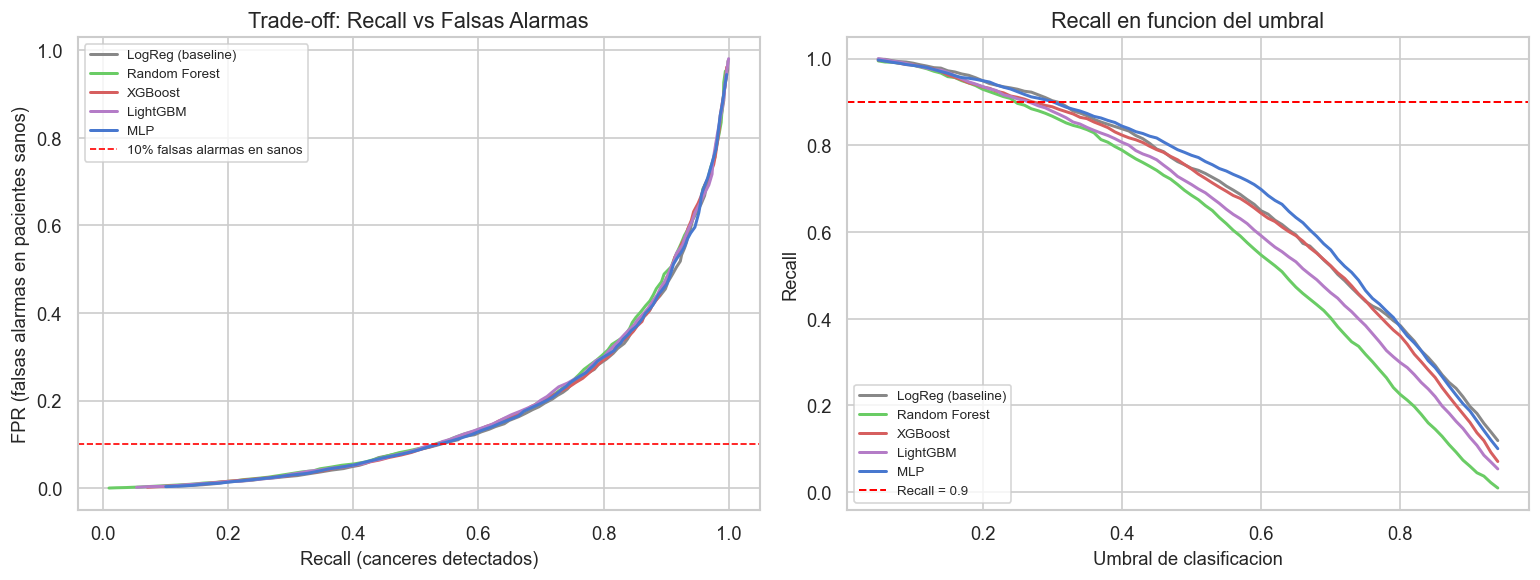

In [27]:
# Grafico: trade-off Recall vs Falsas Alarmas por modelo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

thrs_vis = np.arange(0.05, 0.95, 0.01)

for name, proba in ALL_PROBAS.items():
    rec_v  = [recall_score(y_test, (proba>=t).astype(int), zero_division=0) for t in thrs_vis]
    fpr_v  = [confusion_matrix(y_test, (proba>=t).astype(int)).ravel()[1] /
              max((y_test==0).sum(), 1) for t in thrs_vis]
    col = COLORS.get(name, '#999')

    axes[0].plot(rec_v, fpr_v, color=col, linewidth=1.8, label=name)
    axes[1].plot(thrs_vis, rec_v, color=col, linewidth=1.8, label=name)

axes[0].axhline(0.10, color='red', linestyle='--', linewidth=1,
                label='10% falsas alarmas en sanos')
axes[0].set_xlabel('Recall (canceres detectados)')
axes[0].set_ylabel('FPR (falsas alarmas en pacientes sanos)')
axes[0].set_title('Trade-off: Recall vs Falsas Alarmas')
axes[0].legend(fontsize=8)

axes[1].axhline(TARGET_RECALL, color='red', linestyle='--', linewidth=1.2,
                label=f'Recall = {TARGET_RECALL}')
axes[1].set_xlabel('Umbral de clasificacion')
axes[1].set_ylabel('Recall')
axes[1].set_title('Recall en funcion del umbral')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '26_recall_tradeoff.png'), bbox_inches='tight')
plt.show()

---
## 8.6 Comparación Oracle vs modelos reales

¿Qué fracción del techo teórico alcanza cada modelo?
Responde directamente a la pregunta del enunciado:
*"¿Son los datos suficientemente buenos para anticipar el cáncer?"*

In [28]:
oracle_metrics = {
    'f1':     f1_score(y_test, (oracle_test>=0.5).astype(int)),
    'auc':    roc_auc_score(y_test, oracle_test),
    'pr_auc': average_precision_score(y_test, oracle_test),
}

rows_oracle = []
for name, proba in ALL_PROBAS.items():
    thr = THRESHOLDS[name]
    rows_oracle.append({
        'modelo':       name,
        'f1':           round(f1_score(y_test, (proba>=thr).astype(int)), 4),
        'auc_roc':      round(roc_auc_score(y_test, proba), 4),
        'pr_auc':       round(average_precision_score(y_test, proba), 4),
        'pct_f1_oracle':  round(f1_score(y_test,(proba>=thr).astype(int)) / oracle_metrics['f1'] * 100, 1),
        'pct_auc_oracle': round(roc_auc_score(y_test, proba) / oracle_metrics['auc'] * 100, 1),
    })

df_oracle = pd.DataFrame(rows_oracle).sort_values('auc_roc', ascending=False)
print(f"Oracle (techo):  F1={oracle_metrics['f1']:.4f}  AUC={oracle_metrics['auc']:.4f}"
      f"  PR-AUC={oracle_metrics['pr_auc']:.4f}")
print()
display(df_oracle)
print()
print("pct_oracle = % del techo teorico alcanzado.")
print("Valores cercanos a 100% indican que el modelo extrae casi toda la")
print("informacion recuperable del dataset — la limitacion es el ruido,")
print("no el algoritmo ni el feature engineering.")

Oracle (techo):  F1=0.4853  AUC=0.8362  PR-AUC=0.5907



,modelo,f1,auc_roc,pr_auc,pct_f1_oracle,pct_auc_oracle
0,LogReg (baseline),0.5477,0.8347,0.5933,112.9,99.8
4,MLP,0.5551,0.8322,0.5884,114.4,99.5
2,XGBoost,0.5493,0.8315,0.5847,113.2,99.4
3,LightGBM,0.5490,0.8291,0.5769,113.1,99.2
1,Random Forest,0.5569,0.8273,0.5696,114.7,98.9



pct_oracle = % del techo teorico alcanzado.
Valores cercanos a 100% indican que el modelo extrae casi toda la
informacion recuperable del dataset — la limitacion es el ruido,
no el algoritmo ni el feature engineering.


---
## 8.7 Traducción clínica concreta

Tomamos el modelo recomendado al umbral óptimo de coste asimétrico
y proyectamos los resultados a una escala hospitalaria real.

In [29]:
# Seleccionar el mejor modelo por coste asimetrico
best_cost_name = min(
    [(n, coste_total(y_test, ALL_PROBAS[n], cost_optimal[n]))
     for n in ALL_PROBAS],
    key=lambda x: x[1]
)[0]

best_proba = ALL_PROBAS[best_cost_name]
best_thr   = cost_optimal[best_cost_name]
y_pred_best = (best_proba >= best_thr).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()

# Proyecciones a distintas escalas
prev = y_test.mean()
for n_pacientes in [100, 1000, 10000]:
    n_pos  = int(n_pacientes * prev)
    n_neg  = n_pacientes - n_pos
    recall_val = recall_score(y_test, y_pred_best)
    fpr_val    = fp / (fp + tn + 1e-9)
    tp_p  = int(n_pos * recall_val)
    fn_p  = n_pos - tp_p
    fp_p  = int(n_neg * fpr_val)
    print(f"Por cada {n_pacientes:>6,} pacientes procesados:")
    print(f"  - Canceres detectados: {tp_p:>4}  ({100*recall_val:.1f}% de los {n_pos} reales)")
    print(f"  - Canceres perdidos:   {fn_p:>4}")
    print(f"  - Falsas alarmas:      {fp_p:>4}  ({100*fpr_val:.1f}% de los {n_neg} sanos)")
    print()

# Guardar resumen clinico
clinical_summary = []
for name, proba in ALL_PROBAS.items():
    thr_cost = cost_optimal.get(name, 0.5)
    thr_f1   = THRESHOLDS.get(name, 0.5)
    y_pred_c = (proba >= thr_cost).astype(int)
    y_pred_f = (proba >= thr_f1).astype(int)
    tn_c,fp_c,fn_c,tp_c = confusion_matrix(y_test, y_pred_c).ravel()
    clinical_summary.append({
        'modelo':          name,
        'umbral_coste':    round(thr_cost, 2),
        'recall_coste':    round(recall_score(y_test, y_pred_c), 4),
        'fn_coste':        fn_c,
        'fp_coste':        fp_c,
        'umbral_f1':       round(thr_f1, 2),
        'recall_f1':       round(recall_score(y_test, y_pred_f), 4),
        'fn_f1':           confusion_matrix(y_test, y_pred_f).ravel()[2],
        'auc_roc':         round(roc_auc_score(y_test, proba), 4),
        'brier':           round(brier_score_loss(y_test, proba), 4),
    })

df_clinical = pd.DataFrame(clinical_summary)
df_clinical.to_csv(os.path.join(OUT_TABS, 'clinical_summary.csv'), index=False)

print(f"Modelo recomendado por coste asimetrico: {best_cost_name}")
print(f"Umbral operativo: {best_thr:.2f}")
print(f"Tabla guardada en outputs/tables/clinical_summary.csv")
print()
print("Listo para Notebook 09 - SHAP e Interpretabilidad")

Por cada    100 pacientes procesados:
  - Canceres detectados:   14  (78.5% de los 19 reales)
  - Canceres perdidos:      5
  - Falsas alarmas:        21  (27.1% de los 81 sanos)

Por cada  1,000 pacientes procesados:
  - Canceres detectados:  150  (78.5% de los 192 reales)
  - Canceres perdidos:     42
  - Falsas alarmas:       219  (27.1% de los 808 sanos)

Por cada 10,000 pacientes procesados:
  - Canceres detectados: 1514  (78.5% de los 1928 reales)
  - Canceres perdidos:    414
  - Falsas alarmas:      2189  (27.1% de los 8072 sanos)

Modelo recomendado por coste asimetrico: LogReg (baseline)
Umbral operativo: 0.46
Tabla guardada en outputs/tables/clinical_summary.csv

Listo para Notebook 09 - SHAP e Interpretabilidad
